## PREDICCION DE POTABILIDAD DEL AGUA

# Objetivo

El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de determinar si el agua es potable de acuerdo con las características fisicoquímicas de una muestra.

Se designa la variable binaria 'Potability' como la variable objetivo (y), cuyas opciones son:

0 (no potable)
1 (potable)


In [1]:
# Importo librerías

import pandas as pd               # para trabajar con el dataset y leerlo
import numpy as np                # para trabajar con operaciones matematicas
import matplotlib.pyplot as plt   # para trabajar con graficos

from sklearn.impute import SimpleImputer          # permite reemplazar valores faltantes automáticamente
from sklearn.preprocessing import StandardScaler  # para poder usar StandardScaler

!pip install lazypredict
from lazypredict.Supervised import LazyClassifier # para poder usar LazyClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.9 MB/s eta 0:00:00


In [2]:
# leemos el csv
df=pd.read_csv("water_potability.csv")

# presento las primeras 5 filas

print(df.head())         # Para ver las primeras 5 filas
print(df.shape)          # Para ver las dimensiones

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
(3276, 10)


In [3]:
# Vamos a ver los tipos de datos pertenecientes a cada columna y la cantidad de valores no nulos y algunos de sus parámetros estadísticos

print(df.info())         # Información de las columnas y valores No null
print(df.describe())     # Parametros estadisticos

# verificar que todos los elementos de la columna son del tipo que corresponde, no basta con dtypes porque si el 80% es numerico muestra numerico
# buena practica crear un dataset espejo para no modificar el original REPORTE DE CALIDAD

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085 

In [4]:
# Quiero saber cuantas observaciones hay de cada clase

print('Cantidad de casos por clase')
print(df["Potability"].value_counts())                       # obtengo la cantidad de casos de cada clase
print()                                                      # queria un enter para ver los resultados mas comoda
print('Porcentaje de casos por clase')
print(df["Potability"].value_counts(normalize=True) * 100)   # obtengo el porcentaje de cada clase

Cantidad de casos por clase
Potability
0    1998
1    1278
Name: count, dtype: int64

Porcentaje de casos por clase
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


# RESULTADOS

#### Distribución de la variable objetivo `Potability`

0: 1998 muestras (61 %)

1: 1278 muestras (39 %)


Compruebo que la suma de las observaciones de ambas clases coincide con la cantidad total de filas de mi dataset, con ambos porcentajes sumados comprendiendo el 100%.

Se observa una clara diferencia en la distribución de clases, sin embargo, esta diferencia no presenta un inconveniente, ya que la clase minoritaria representa el 39,01 % de las muestras totales.

In [5]:
# Analisis de valores faltantes

print('Valores Faltantes por columna')
print(df.isnull().sum())         # detecta valores faltantes y suma la cantidad de casos
print()
print('Porcentaje de valores faltantes por columna')
print(df.isnull().mean() * 100)  # se calcula el porcentaje
print()
missing = df.isnull().sum()

print(missing[missing > 0])

#print(df.columns)        # Nombres de las columnas
#print(df.dtypes)         # Tipo de datos
#print(df.isna().sum())   # True si es nan, Falso sino. Al agregar sum() presenta la suma

Valores Faltantes por columna
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Porcentaje de valores faltantes por columna
ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64


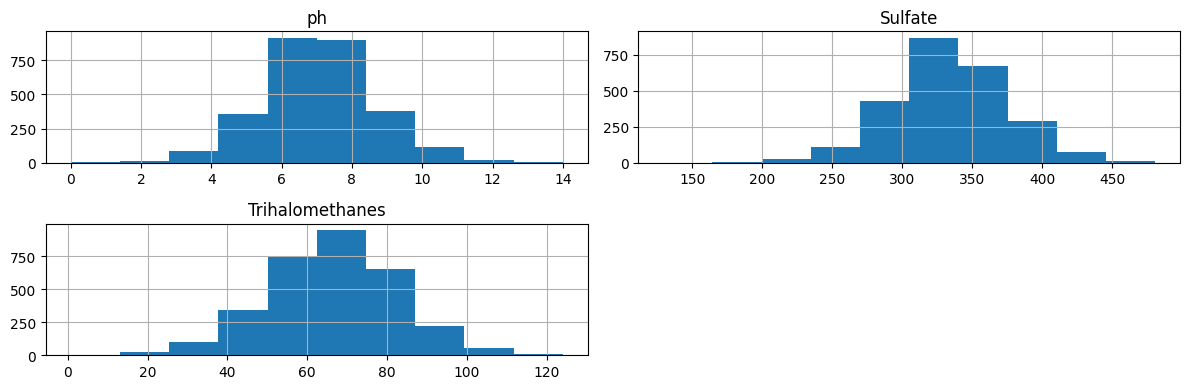

In [6]:
# Vamos a examinar las variables con datos faltantes

df[["ph", "Sulfate", "Trihalomethanes"]].hist(figsize=(12, 4))

plt.tight_layout()
plt.show()

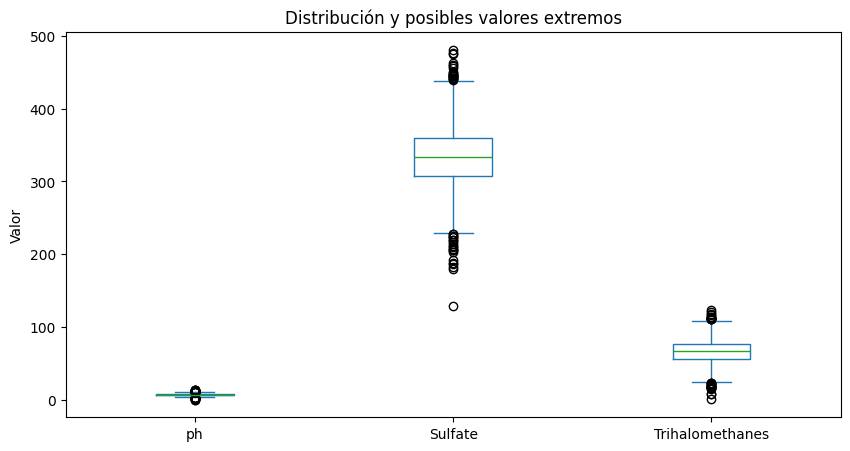

In [7]:
# Boxplot

df[["ph", "Sulfate", "Trihalomethanes"]].plot(
    kind="box",
    figsize=(10, 5)
)

plt.title("Distribución y posibles valores extremos")
plt.ylabel("Valor")
plt.show()

In [8]:
# Datos de Ph, sulfato y Trihalomethanes faltantes dependiendo de la clase de Potability

print(df.groupby("Potability")[["ph", "Sulfate", "Trihalomethanes"]].apply(
    lambda x: x.isnull().sum()
))                                                                # Totales
print()
print(df.groupby("Potability")[["ph", "Sulfate", "Trihalomethanes"]].apply(
    lambda x: x.isnull().mean() * 100
))                                                                # Porcentuales

             ph  Sulfate  Trihalomethanes
Potability                               
0           314      488              107
1           177      293               55

                   ph    Sulfate  Trihalomethanes
Potability                                       
0           15.715716  24.424424         5.355355
1           13.849765  22.926448         4.303599


# Valores faltantes según variable objetivo

Los valores faltantes en las muestras corresponden ph, Sulfato y Trihalomethanes.

### `ph`: 16% (Potabilidad = 0) y 14% (Potabilidad = 1)

### `Sulfato`: 24% (Potabilidad = 0) y 23% (Potabilidad = 1)

### `Trihalomethanes`: 5% (Potabilidad = 0) y 4% (Potabilidad = 1)

Al analizar su distribución según su Potabilidad, se observa que los porcentajes de valores faltantes son similares entre sí.

In [9]:
# Analisis estadistico de la variables predictorias

df.drop("Potability", axis=1).describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000


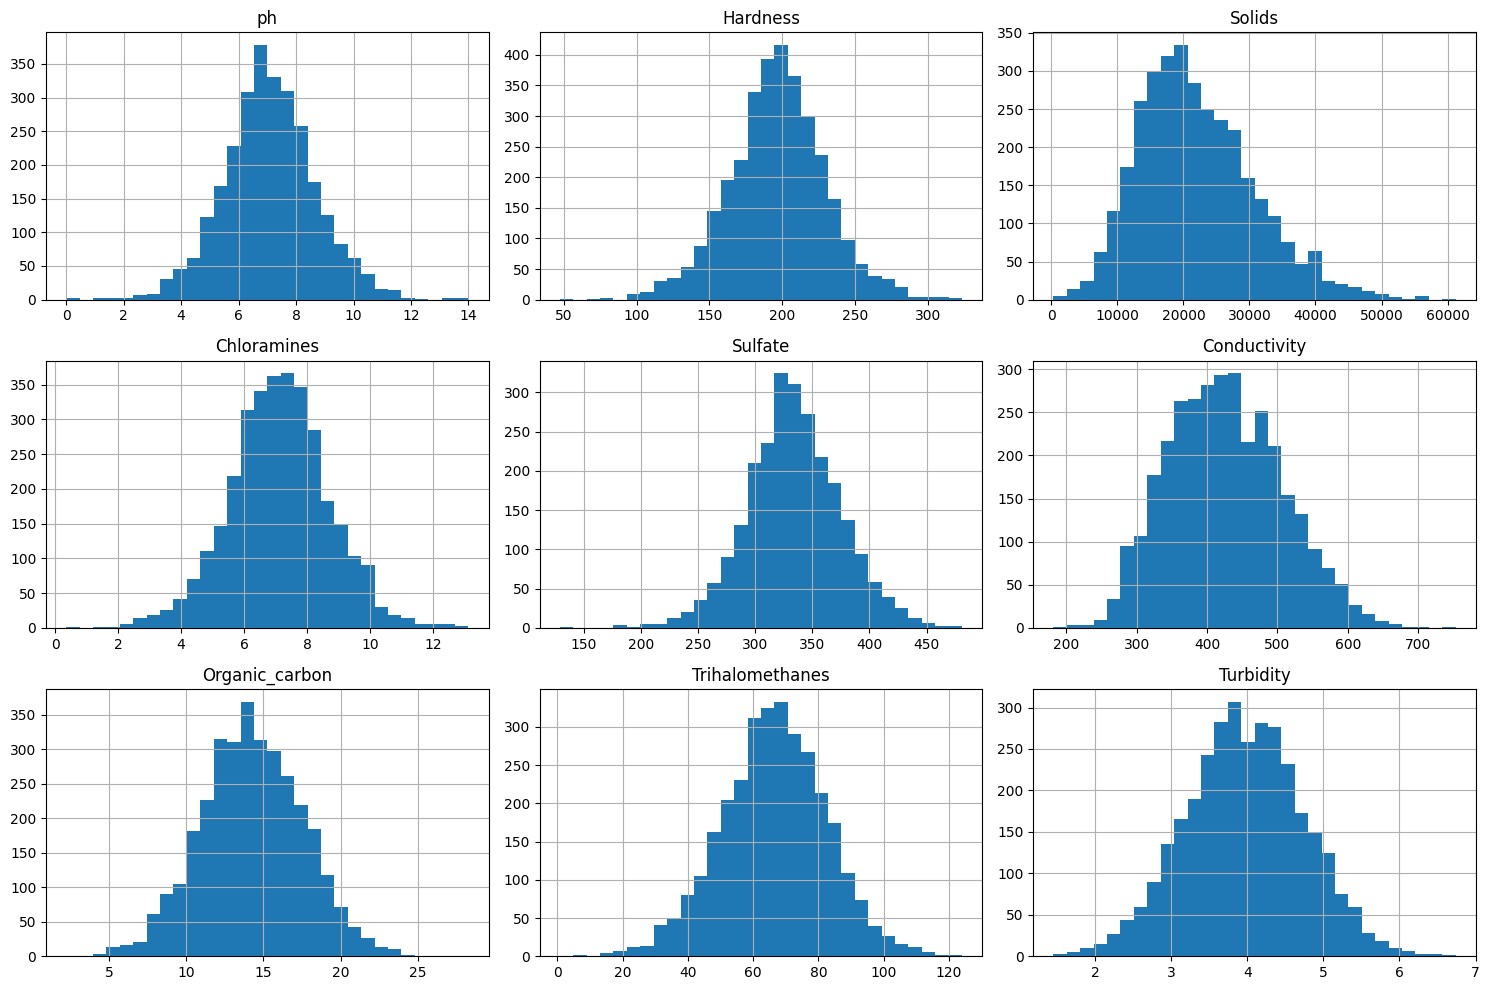

In [10]:
# Distribución de las variables predictoras

df.drop("Potability", axis=1).hist(   # histograma de todas las variables menos Potability
    figsize=(15, 10),                 # dimensiones del histograma
    bins=30                           # distribuye en 30 intervalos
)

plt.tight_layout()
plt.show()

# Observaciones

`ph`: distribución aproximadamente simétrica y centrada cerca de 7, aunque aparecen algunos valores extremos.

`Hardness`: bastante concentrada alrededor de 200 y con forma aproximadamente de campana.

`Solids`: es la que muestra una asimetría positiva más evidente: hay una cola larga hacia valores altos.

`Chloramines`: bastante centrada, con cierta cola hacia ambos lados.

`Sulfate`: relativamente simétrica, aunque presenta algunos valores alejados.

`Conductivity`: distribución bastante amplia y con cierta asimetría hacia valores altos.

`Organic_carbon`: aproximadamente simétrica, aunque ligeramente desplazada hacia valores altos.

`Trihalomethanes`: bastante cercana a una distribución de campana, con algunos valores extremos.

`Turbidity`: también bastante concentrada y aproximadamente simétrica.

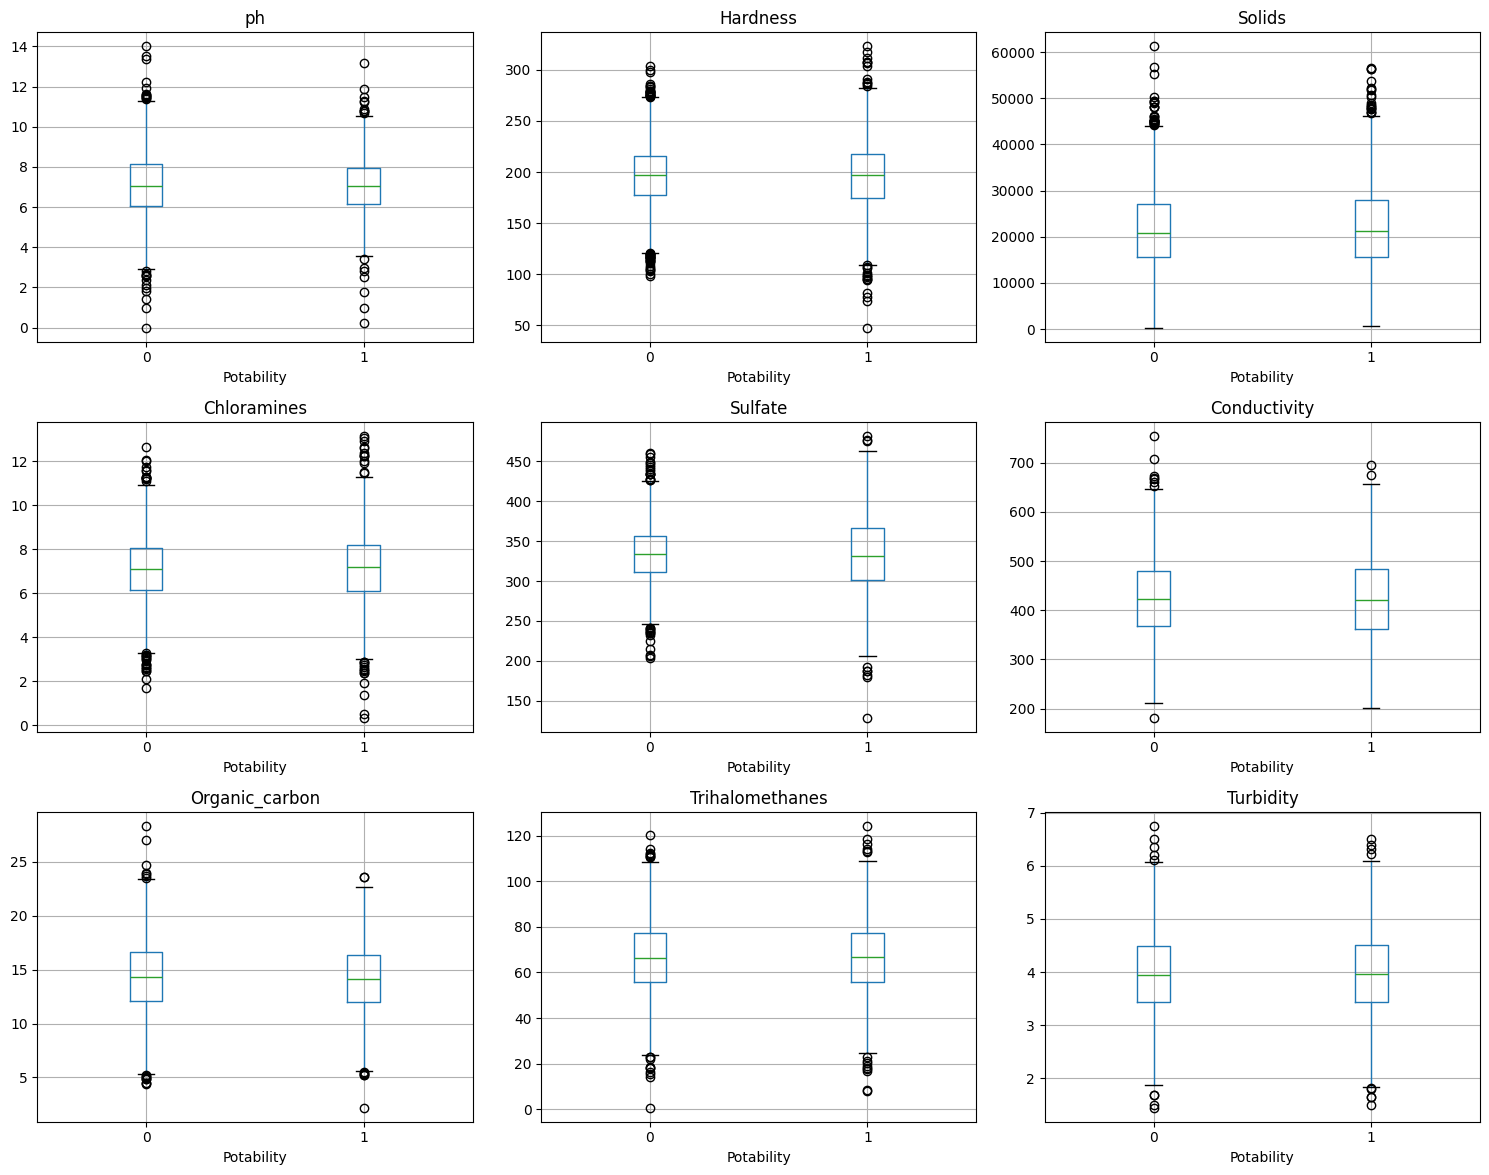

In [11]:
# ¿La distribución del ph es diferente entre las muestras potables y las no potables?

# Comparación de las variables predictoras según Potability

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

variables = df.drop("Potability", axis=1).columns

for ax, variable in zip(axes.flat, variables):
    df.boxplot(
        column=variable,
        by="Potability",
        ax=ax
    )
    ax.set_title(variable)
    ax.set_xlabel("Potability")

plt.suptitle("")
plt.tight_layout()

plt.show()

### Relación entre las variables predictoras y la potabilidad

Se utilizaron boxplots para comparar la distribución de cada variable
predictora entre las clases de `Potability`.

En términos generales, las distribuciones de las variables presentan un
considerable solapamiento entre las clases 0 y 1. No se observa una variable
que presente una separación claramente marcada entre agua potable y no
potable.

Algunas variables, como `Sulfato` y `Solidos`, muestran diferencias algo más
visibles en sus medianas y dispersión, aunque el solapamiento entre ambas
clases continúa siendo importante.

También se observan numerosos valores potencialmente atípicos en distintas
variables. Estos valores no se eliminan automáticamente, ya que no se cuenta
con evidencia suficiente para considerarlos errores de medición y podrían
contener información relevante para la clasificación.

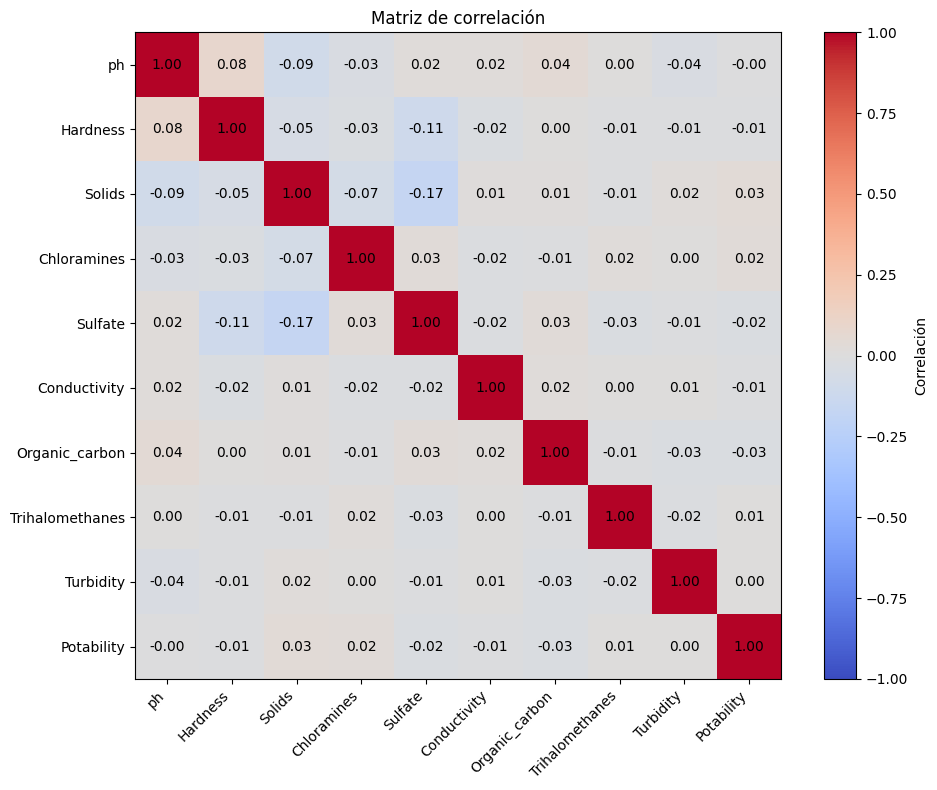

In [12]:
# Matriz de correlación para observar correlacion entre las variables

corr = df.corr()                                    # se calcula la correlacion entre las variables

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)  # la matriz se convierte en un mapa de colores

plt.colorbar(label="Correlación")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

# Agregamos los valores numéricos
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

# Análisis de correlación

Se calculó la matriz de correlación de Pearson entre las variables
predictoras y la variable objetivo `Potability`.

Las correlaciones entre las variables predictoras y `Potability` resultaron
cercanas a cero. La mayor correlación en valor absoluto fue la correspondiente
a `Organic_carbon` (-0,03) y `Solids` (0,03), por lo que no se observa una
relación lineal fuerte entre ninguna variable individual y la potabilidad.

Asimismo, las correlaciones entre las variables predictoras son bajas. La
mayor correlación en valor absoluto se observa entre `Solids` y `Sulfate`
(-0,17), lo que no representa una relación lineal fuerte.

Estos resultados no implican que las variables carezcan de capacidad
predictiva, ya que la matriz de correlación solamente permite evaluar
relaciones lineales y los modelos de clasificación pueden detectar relaciones
no lineales o interacciones entre variables.

## Finalización del EDA
##        y
## Preparación de datos


In [13]:
# Separación de variables predictorias (X) y variable objetivo (y)

X = df.drop("Potability", axis=1)
y = df["Potability"]

# podemos corroborar las nuevas dimensiones
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (3276, 9)
Dimensiones de y: (3276,)


In [14]:
# Separación entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,           # 80% entrenamiento, 20% prueba
    random_state=15,          # semilla 15
    stratify=y                # mantiene proporción entre entrenamiento y prueba
)

# Compruebo dimensiones y distribuciones
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución de y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de y_test:")
print(y_test.value_counts(normalize=True))

X_train: (2620, 9)
X_test: (656, 9)
y_train: (2620,)
y_test: (656,)

Distribución de y_train:
Potability
0    0.609924
1    0.390076
Name: proportion, dtype: float64

Distribución de y_test:
Potability
0    0.609756
1    0.390244
Name: proportion, dtype: float64


In [15]:
# Relleno de datos faltantes con la mediana

# Decidimos durante el EDA que la mediana es una alternativa razonable
# y además es menos sensible a valores extremos que la media.

imputer = SimpleImputer(strategy="median")  # Configura cómo queremos imputar

imputer.fit(X_train)                        # Calcula las medianas usando X_train

X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

import numpy as np

print("Valores faltantes en X_train:", np.isnan(X_train_imputed).sum())
print("Valores faltantes en X_test:", np.isnan(X_test_imputed).sum())

Valores faltantes en X_train: 0
Valores faltantes en X_test: 0


In [16]:
# Se crea un objeto scaler que sabe cómo estandarizar nuestras variables

scaler = StandardScaler()

# StandardScaler recorre cada una de las 9 variables y calcula, usando solamente
# X_train_imputed: la media y el desvio estándar
scaler.fit(X_train_imputed)
X_train_scaled = scaler.transform(X_train_imputed)

In [17]:
# Esto es importante porque queremos que el test sea transformado con las reglas aprendidas del entrenamiento

X_test_scaled = scaler.transform(X_test_imputed)

print("Media aproximada de X_train_scaled:")
print(X_train_scaled.mean(axis=0))

print("\nDesvío estándar aproximado de X_train_scaled:")
print(X_train_scaled.std(axis=0))

Media aproximada de X_train_scaled:
[ 5.54603013e-16  1.89839662e-16 -1.38989753e-17  2.03399638e-16
 -7.05118745e-16  1.81703677e-16  1.42888246e-16  1.62719710e-16
  1.89839662e-16]

Desvío estándar aproximado de X_train_scaled:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Estandarización de variables

Se aplicó `StandardScaler` a las variables predictoras utilizando únicamente
el conjunto de entrenamiento. El escalador aprendió la media y el desvío
estándar de cada variable a partir de `X_train` y posteriormente se aplicó
la misma transformación a `X_test`.

Como comprobación, las variables estandarizadas en `X_train` presentan una
media aproximadamente igual a 0 y un desvío estándar igual a 1.

# Por ahora tenemos:

X_train_imputed    → imputados, sin escalar

X_test_imputed     → imputados, sin escalar
#
y
#
X_train_scaled     → imputados + escalados

X_test_scaled      → imputados + escalados

.

#### Como debemos probar más de un modelo, dependiendo del modelo que elijamos se toma un `X_train` u otro:
#

Regresión logística: X_train_scaled

KNN:                 X_train_scaled

SVM:                 X_train_scaled

Arbol de desiciones: X_train_imputed

Random Forest:       X_train_imputed

XGBoost:             X_train_imputed




In [18]:
# creamos el objeto clf que posteriormente se encargará de ejecutar los clasificadores

clf = LazyClassifier(
    verbose=0,              # evita que nos llene la salida de mensajes durante la ejecución
    ignore_warnings=True    # evita que advertencias de algunos modelos hagan que la salida sea difícil de leer
)

In [19]:
# Se hace que LazyPredict entrene y compare los clasificadores

models, predictions = clf.fit(
    X_train_scaled,             # variables de entrenamiento, ya imputadas y estandarizadas
    X_test_scaled,              # variables de prueba, transformadas con el mismo scaler
    y_train,                    # respuestas reales del conjunto de entrenamiento
    y_test                      # respuestas reales del conjunto de prueba
)

models.sort_values("Accuracy", ascending=False)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
QuadraticDiscriminantAnalysis,0.702744,0.643750,0.714238,0.674822,0.709906,0.702744,0.056237
ExtraTreesClassifier,0.696646,0.636641,0.699331,0.667393,0.702498,0.696646,0.541917
SVC,0.689024,0.624062,0.722363,0.653665,0.698128,0.689024,0.451447
RandomForestClassifier,0.678354,0.619531,0.707017,0.649714,0.675639,0.678354,1.567699
NuSVC,0.664634,0.627969,0.693955,0.655011,0.655469,0.664634,0.633455
GaussianNB,0.655488,0.580391,0.616445,0.603615,0.657685,0.655488,0.027738
LGBMClassifier,0.652439,0.606719,0.680732,0.636056,0.640290,0.652439,0.221828
BaggingClassifier,0.649390,0.600000,0.640718,0.629730,0.636335,0.649390,0.394476
XGBClassifier,0.641768,0.607109,0.659395,0.633603,0.632144,0.641768,0.315319


### Propuesta de modelos

Ser proponen los siguientes modelos ya que obtuvieron mayor accuracy. Y el XGBoost, por ser parte de los modelos propuesto en el proyecto:

-Quadratic Discriminant Analysis

-Extra Trees

-SVC

-Random Forest

-XGBoost

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [21]:
# Creamos un diccionario con los modelos

models = {
    "QDA": QuadraticDiscriminantAnalysis(),
    "Extra Trees": ExtraTreesClassifier(random_state=15),       # se fija una semilla (15)
    "SVC": SVC(),
    "Random Forest": RandomForestClassifier(random_state=15),
    "XGBoost": XGBClassifier(
        random_state=15,
        eval_metric="logloss"
    )
}

# Pipeline

In [22]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

In [23]:
# Se divide X_train en varios subconjuntos y entrena/evalua cada modelo varias veces. Así no se depende de una única división de los datos.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=15
)

# Validación cruzada

#### Se evalua los 5 modelos mediante validación cruzada

Accuracy → proporción total de predicciones correctas.

Precision → de los casos que el modelo clasificó como potables, cuántos realmente lo eran.

Recall → de los casos realmente potables, cuántos logró detectar.

F1 → equilibrio entre precision y recall.

ROC-AUC → capacidad del modelo para distinguir entre las dos clases.

In [24]:
# Validación cruzada

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Modelo": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

In [25]:
# Visualización de los resultados por modelo

results_df = pd.DataFrame(results)

results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
2,SVC,0.670611,0.705330,0.266093,0.386012,0.675097
0,QDA,0.666794,0.652149,0.316982,0.426007,0.672351
1,Extra Trees,0.655725,0.634458,0.276853,0.385203,0.658822
4,XGBoost,0.641603,0.554810,0.412874,0.473247,0.651737
3,Random Forest,0.655725,0.613080,0.314041,0.415067,0.650915


# Criterio

Entre las posibilidades, un falso positivo es más peligroso porque indica que un cuerpo de agua es potable cuando en realidad no lo es. Por lo que se quiere minimizarlos .En este caso se busca un Recall(0) alto

In [26]:
# Calculo de Recall para 0

from sklearn.metrics import recall_score, make_scorer

recall_no_potable = make_scorer(
    recall_score,
    pos_label=0
)

In [27]:
#

results_no_potable = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=recall_no_potable
    )

    results_no_potable.append({
        "Modelo": name,
        "Recall_no_potable": scores["test_score"].mean()
    })

In [28]:
# Recall no potable según el modelo

results_no_potable_df = pd.DataFrame(results_no_potable)

results_no_potable_df.sort_values(
    "Recall_no_potable",
    ascending=False
)

,Modelo,Recall_no_potable
2,SVC,0.929287
1,Extra Trees,0.898009
0,QDA,0.890492
3,Random Forest,0.874238
4,XGBoost,0.787868


Como un modelo puede ser muy conservador, con un `Recall` muy alto, y clasificar casi toda agua como no potable. Eso reduce los falsos positivos pero puede aumentar los falsos negativos. Para ello

In [29]:
# Matriz de confusión para SVC usando validación cruzada

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

svc_pred = cross_val_predict(
    pipelines["SVC"],
    X_train,
    y_train,
    cv=cv
)

cm_svc = confusion_matrix(y_train, svc_pred)

cm_svc

array([[1485,  113],
       [ 750,  272]])

In [30]:
# Matriz de confusión para Extra Trees usando validación cruzada

extra_trees_pred = cross_val_predict(
    pipelines["Extra Trees"],
    X_train,
    y_train,
    cv=cv
)

cm_extra_trees = confusion_matrix(y_train, extra_trees_pred)

cm_extra_trees

array([[1435,  163],
       [ 739,  283]])

# Selección de modelos para optimización

A partir de la validación cruzada se compararon cinco modelos de clasificación
utilizando distintas métricas.

Dado el objetivo del problema, se decidió priorizar la capacidad de detectar
correctamente las muestras de agua no potable (`Potability = 0`). El error que
se busca minimizar especialmente es el falso positivo: clasificar como potable
una muestra que en realidad no lo es.

Por este motivo, se utilizó el **Recall de la clase 0** como métrica principal
para esta etapa.

Los resultados fueron:

- **SVC:** Recall de clase 0 = 92,93 %
- **Extra Trees:** Recall de clase 0 = 89,80 %
- **QDA:** Recall de clase 0 = 89,05 %
- **Random Forest:** Recall de clase 0 = 87,42 %
- **XGBoost:** Recall de clase 0 = 78,79 %

A partir de estos resultados se seleccionaron **SVC y Extra Trees** para la
etapa de optimización de hiperparámetros mediante `GridSearchCV`.

La selección no implica que estos modelos sean superiores en todas las
métricas, sino que presentan los mejores resultados según la métrica priorizada
para el objetivo definido.

In [31]:
# Se prueban diferentes combinaciones

param_grid_svc = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale"]
}

# son un total de 6 combinaciones

In [32]:
#

from sklearn.model_selection import GridSearchCV

grid_svc = GridSearchCV(
    estimator=pipelines["SVC"],
    param_grid=param_grid_svc,
    scoring=recall_no_potable,
    cv=cv,
    n_jobs=-1
)

In [33]:
# Es un total de 30 entrenamientos (6*5)

grid_svc.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=15, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model', SVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10], 'model__gamma': ['scale'],
                         'model__kernel': ['linear', 'rbf']},
             scoring=make_scorer(recall_score, response_method='predict', pos_label=0))

In [34]:
# Ahora con Extra Trees

pipelines["Extra Trees"]

recall_no_potable

param_grid_extra_trees = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# son 24 combinaciones

# crear el gridSearch
grid_extra_trees = GridSearchCV(
    estimator=pipelines["Extra Trees"],
    param_grid=param_grid_extra_trees,
    scoring=recall_no_potable,
    cv=cv,
    n_jobs=-1
)

# entrenar
grid_extra_trees.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=15, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        ExtraTreesClassifier(random_state=15))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring=make_scorer(recall_score, response_method='predict', pos_label=0))

In [35]:
# Vemos los hiperparametros

print("Mejores hiperparámetros:")
print(grid_extra_trees.best_params_)

Mejores hiperparámetros:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [36]:
# Vemos el mejor Recall

print("Mejor Recall clase 0:")
print(grid_extra_trees.best_score_)

Mejor Recall clase 0:
0.9856112852664577


In [37]:
print("SVC optimizado:")
print("Hiperparámetros:", grid_svc.best_params_)
print("Recall(0):", grid_svc.best_score_)

print()

print("Extra Trees optimizado:")
print("Hiperparámetros:", grid_extra_trees.best_params_)
print("Recall(0):", grid_extra_trees.best_score_)

SVC optimizado:
Hiperparámetros: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Recall(0): 1.0

Extra Trees optimizado:
Hiperparámetros: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Recall(0): 0.9856112852664577


In [38]:
# Predicciones sobre el conjunto de prueba

y_pred_svc = grid_svc.best_estimator_.predict(X_test)
y_pred_extra_trees = grid_extra_trees.best_estimator_.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("SVC optimizado")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc))
print("Recall clase 1:", recall_score(y_test, y_pred_svc))
print("Recall clase 0:", recall_score(y_test, y_pred_svc, pos_label=0))
print("F1:", f1_score(y_test, y_pred_svc))

print("\nExtra Trees optimizado")
print("Accuracy:", accuracy_score(y_test, y_pred_extra_trees))
print("Precision:", precision_score(y_test, y_pred_extra_trees))
print("Recall clase 1:", recall_score(y_test, y_pred_extra_trees))
print("Recall clase 0:", recall_score(y_test, y_pred_extra_trees, pos_label=0))
print("F1:", f1_score(y_test, y_pred_extra_trees))

SVC optimizado
Accuracy: 0.6097560975609756
Precision: 0.0
Recall clase 1: 0.0
Recall clase 0: 1.0
F1: 0.0

Extra Trees optimizado
Accuracy: 0.6600609756097561
Precision: 0.8837209302325582
Recall clase 1: 0.1484375
Recall clase 0: 0.9875
F1: 0.25418060200668896


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Resultados

El modelo SVC obtuvo:
- Recall(0) = 1.00

- Recall(1) = 0.00

- Precision = 0.00

- F1        = 0.00

- Accurracy = 0.00

El modelo Extra Trees obtuvo:

- Recall(0) = 0.9875

- Recall(1) = 0.1484

- Precision = 0.8837

- F1        = 0.2542

- Accurracy = 0.6601

El modelo SVC por lo tanto predice practicamente todas las aguas como no potables a costa de no detactar las aguas potables. En cambio, el modelo Extra Trees identifica algunas aguas como potables.



In [39]:
# Matrices de confusion

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_svc_test = confusion_matrix(y_test, y_pred_svc)
cm_extra_trees_test = confusion_matrix(y_test, y_pred_extra_trees)

print("Matriz de confusión - SVC")
print(cm_svc_test)

print("\nMatriz de confusión - Extra Trees")
print(cm_extra_trees_test)



Matriz de confusión - SVC
[[400   0]
 [256   0]]

Matriz de confusión - Extra Trees
[[395   5]
 [218  38]]


In [40]:
# Se modifica la métrica de GridSearch para SVC

grid_svc_balanced = GridSearchCV(
    estimator=pipelines["SVC"],
    param_grid=param_grid_svc,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1
)

grid_svc_balanced.fit(X_train, y_train)

print("Mejores parámetros SVC:")
print(grid_svc_balanced.best_params_)

print("Mejor Balanced Accuracy:")
print(grid_svc_balanced.best_score_)




# para Extra Trees

grid_extra_trees_balanced = GridSearchCV(
    estimator=pipelines["Extra Trees"],
    param_grid=param_grid_extra_trees,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1
)

grid_extra_trees_balanced.fit(X_train, y_train)

print("Mejores parámetros Extra Trees:")
print(grid_extra_trees_balanced.best_params_)

print("Mejor Balanced Accuracy:")
print(grid_extra_trees_balanced.best_score_)



Mejores parámetros SVC:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Mejor Balanced Accuracy:
0.6155623087601888
Mejores parámetros Extra Trees:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Mejor Balanced Accuracy:
0.5903910334108413


In [41]:
# hacemos las predicciones

y_pred_svc_balanced = grid_svc_balanced.best_estimator_.predict(X_test)
y_pred_extra_trees_balanced = grid_extra_trees_balanced.best_estimator_.predict(X_test)

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

print("SVC optimizado por Balanced Accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_svc_balanced))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_svc_balanced))
print("Precision:", precision_score(y_test, y_pred_svc_balanced, zero_division=0))
print("Recall clase 1:", recall_score(y_test, y_pred_svc_balanced))
print("Recall clase 0:", recall_score(y_test, y_pred_svc_balanced, pos_label=0))
print("F1:", f1_score(y_test, y_pred_svc_balanced))

print("\nExtra Trees optimizado por Balanced Accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_extra_trees_balanced))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_extra_trees_balanced))
print("Precision:", precision_score(y_test, y_pred_extra_trees_balanced, zero_division=0))
print("Recall clase 1:", recall_score(y_test, y_pred_extra_trees_balanced))
print("Recall clase 0:", recall_score(y_test, y_pred_extra_trees_balanced, pos_label=0))
print("F1:", f1_score(y_test, y_pred_extra_trees_balanced))

SVC optimizado por Balanced Accuracy
Accuracy: 0.6844512195121951
Balanced Accuracy: 0.642109375
Precision: 0.6353591160220995
Recall clase 1: 0.44921875
Recall clase 0: 0.835
F1: 0.5263157894736842

Extra Trees optimizado por Balanced Accuracy
Accuracy: 0.6951219512195121
Balanced Accuracy: 0.628359375
Precision: 0.7545454545454545
Recall clase 1: 0.32421875
Recall clase 0: 0.9325
F1: 0.453551912568306


# Cambio al optimizar por Balance Accurracy

Los `Recall` de ambos modelos cambian considerablemente. Al optimizarlos por `Recall(0)` se produjeron modelos demasiado conservadores. Siendo el caso más extremo el SVC. Finalmente obtenemos mejores métricas con:

SVC:
- Balanced Accuracy = 0.63
- Recall 1 = 0.45
- F1 = 0.53

Extra Trees:
-  Accurracy = 0.70
- Recall 0 = 0.93
- Precision = 0.75

No hay un modelo claramente mejor que el otro. Sin embargo, el interés principal es evitar clasificar un cuerpo de agua no potable como potable, por lo que elegir el modelo con mayor `Recall(0)` es la elección tomada.

In [43]:
# Matrices de confusion de modelos balanceado por Accurracy

from sklearn.metrics import confusion_matrix

cm_svc_balanced = confusion_matrix(y_test, y_pred_svc_balanced)
cm_extra_trees_balanced = confusion_matrix(
    y_test,
    y_pred_extra_trees_balanced
)

print("SVC:")
print(cm_svc_balanced)

print("\nExtra Trees:")
print(cm_extra_trees_balanced)

SVC:
[[334  66]
 [141 115]]

Extra Trees:
[[373  27]
 [173  83]]


SVC identifica mejor la clase potable. Extra Trees identifica mejor la clase no potable y comete menos falsos positivos.

In [44]:

import shap

In [45]:
modelo_final = grid_extra_trees_balanced.best_estimator_.named_steps["model"]

modelo_final

ExtraTreesClassifier(min_samples_split=5, n_estimators=200, random_state=15)

In [46]:
# transformar los datos

X_test_imputed = grid_extra_trees_balanced.best_estimator_.named_steps["imputer"].transform(X_test)

X_test_scaled = grid_extra_trees_balanced.best_estimator_.named_steps["scaler"].transform(X_test_imputed)

In [47]:
# crear el explicador Sharp

explainer = shap.TreeExplainer(modelo_final)

In [48]:
# calcular Sharp

shap_values = explainer.shap_values(X_test_scaled)

type(shap_values)
np.shape(shap_values)

(656, 9, 2)

In [49]:
# se crean los valores Shsrp de clase potable

shap_values_potable = shap_values[:, :, 1]

print(shap_values_potable.shape)

(656, 9)


In [50]:
# se preparan los nombres de las variables

feature_names = X_test.columns.tolist()

feature_names

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

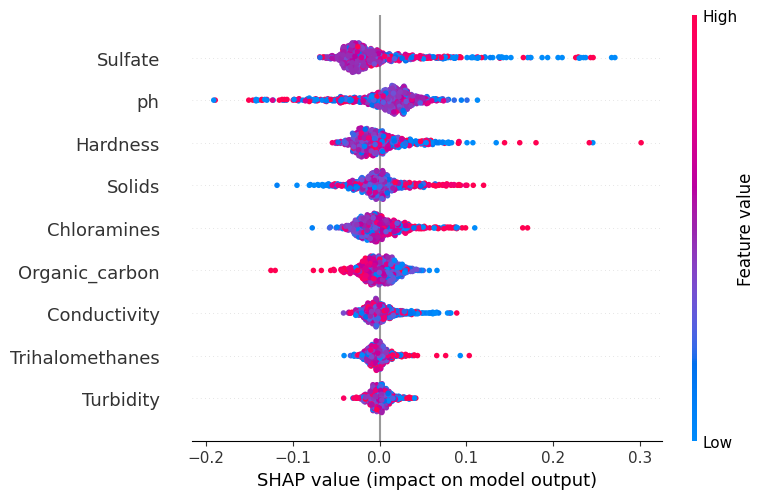

In [51]:
# Grafico Sharp

shap.summary_plot(
    shap_values_potable,
    X_test_scaled,
    feature_names=feature_names
)

Sulfate: es claramente la variable con mayor influencia. Los valores altos aparecen frecuentemente asociados a valores SHAP negativos.

ph: es la segunda variable más importante y muestra una relación menos simple: hay valores altos y bajos distribuidos a ambos lados. Esto indica que la relación entre pH y la predicción no es simplemente "más pH = más potable" o viceversa.

Hardness: también presenta una dispersión considerable. Hay algunos valores altos que generan contribuciones positivas importantes, aunque la relación tampoco es completamente lineal.

Solids: presenta valores bajos asociados principalmente con contribuciones negativas y valores altos que llegan a generar contribuciones positivas.

Turbidity: tiene los valores SHAP más concentrados alrededor de cero, por lo que su impacto global sobre las predicciones del modelo es menor que el de las demás variables.

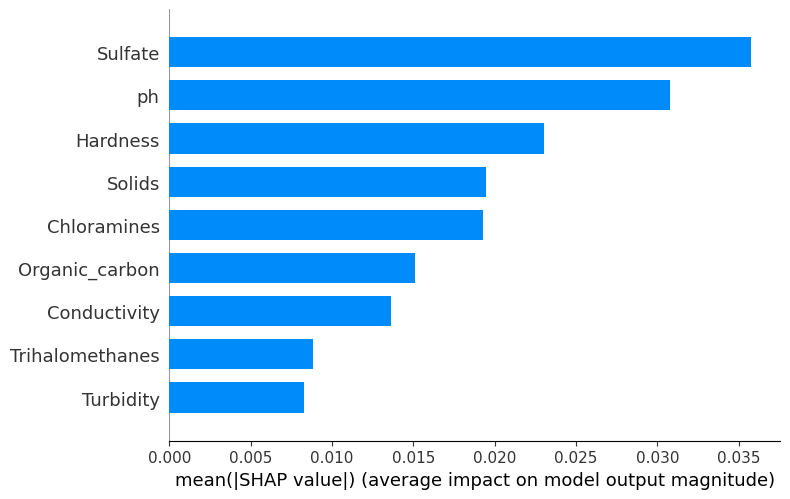

In [52]:
# segundo grafico sharp para ayuda en interpretacion

shap.summary_plot(
    shap_values_potable,
    X_test_scaled,
    feature_names=feature_names,
    plot_type="bar"
)

In [53]:
# Buscamos un resumen mas completo

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_extra_trees_balanced,
    target_names=["No potable", "Potable"]
))

              precision    recall  f1-score   support

  No potable       0.68      0.93      0.79       400
     Potable       0.75      0.32      0.45       256

    accuracy                           0.70       656
   macro avg       0.72      0.63      0.62       656
weighted avg       0.71      0.70      0.66       656



In [55]:
# Calculamos el ROC-AUC

y_proba_extra_trees = (
    grid_extra_trees_balanced
    .best_estimator_
    .predict_proba(X_test)[:, 1]
)

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba_extra_trees)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7108447265625


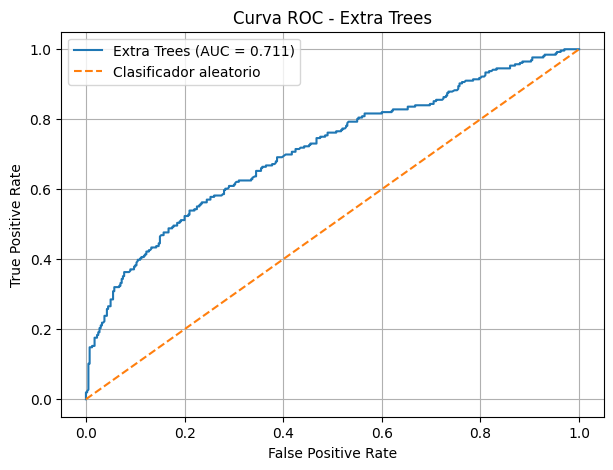

In [56]:
# podemos visualizar cómo cambia el desempeño del clasificador al modificar el umbral de decisión

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_extra_trees
)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Extra Trees (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Clasificador aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Extra Trees")
plt.legend()
plt.grid()
plt.show()

# Conclusiones

El objetivo de este proyecto fue desarrollar un modelo de Machine Learning capaz de clasificar muestras de agua según su potabilidad, utilizando como variable objetivo Potability, donde 0 representa agua no potable y 1 agua potable.

Durante el análisis exploratorio se identificaron valores faltantes en ph, Sulfato y Trihalomethanes. Estos valores fueron imputados utilizando la mediana, calculada únicamente sobre el conjunto de entrenamiento para evitar fuga de información. Posteriormente, las variables fueron estandarizadas mediante StandardScaler. La división entre entrenamiento y prueba se realizó utilizando estratificación, manteniendo una proporción similar de ambas clases en ambos conjuntos.

Se compararon cinco algoritmos mediante validación cruzada: QDA, Extra Trees, SVC, Random Forest y XGBoost. Debido al objetivo de minimizar el riesgo de clasificar una muestra no potable como potable, inicialmente se utilizó el Recall de la clase 0 como métrica prioritaria. Sin embargo, esta estrategia produjo modelos excesivamente conservadores, especialmente el SVC, que alcanzó un Recall de la clase 0 de 1, pero clasificó todas las muestras como no potables en el conjunto de prueba.

Por este motivo, se realizó una segunda optimización mediante GridSearchCV, utilizando Balanced Accuracy como métrica de optimización. El modelo seleccionado fue Extra Trees, con n_estimators=200 y min_samples_split=5, entre otros parámetros. En el conjunto de prueba obtuvo una accuracy de 69,51 %, una Balanced Accuracy de 62,84 %, un Recall de 93,25 % para la clase no potable y un ROC-AUC de 0,7108. La matriz de confusión mostró 373 verdaderos negativos, 27 falsos positivos, 173 falsos negativos y 83 verdaderos positivos.

Estos resultados muestran que el modelo presenta un comportamiento conservador: identifica correctamente una alta proporción de las muestras no potables y mantiene relativamente bajo el número de falsos positivos, pero presenta dificultades para identificar muestras potables, cuyo Recall fue de 32,42 %. Por lo tanto, el modelo no debe interpretarse como un clasificador perfecto y existe margen para mejorar el equilibrio entre ambas clases.

Finalmente, mediante el análisis SHAP se estudió la contribución de las variables a las predicciones del modelo. El Sulfato presentó la mayor importancia global, seguida por ph, Hardness, Solids y Chloramines. Esto muestra que algunas variables con baja correlación lineal con la variable objetivo pueden igualmente aportar información relevante al modelo, posiblemente a través de relaciones no lineales e interacciones entre variables.

En conjunto, el proyecto permitió construir un flujo reproducible de Machine Learning que abarca desde el análisis exploratorio y el preprocesamiento hasta la optimización, evaluación e interpretación del modelo. Los resultados también muestran la importancia de seleccionar las métricas de evaluación de acuerdo con el objetivo del problema, ya que optimizar una única métrica puede producir modelos con comportamientos no deseados sobre la otra clase.